In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define Known Data Points
# x and y represent the coordinates through which the spline must pass.
x_data = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y_data = np.array([1.0, 2.5, 2.0, 0.5, 1.5, 3.0])

print("x data points:", x_data)
print("y data points:", y_data)

x data points: [0. 1. 2. 3. 4. 5.]
y data points: [1.  2.5 2.  0.5 1.5 3. ]


In [2]:
# Step 2: Calculate Step Sizes
n = len(x_data)
h = np.zeros(n - 1)

# Loop through to calculate the distance between consecutive x points
for i in range(n - 1):
    h[i] = x_data[i+1] - x_data[i]

print("Step sizes (h):", h)

Step sizes (h): [1. 1. 1. 1. 1.]


In [4]:
# Step 3: Set Up and Solve the Tridiagonal System

# The system has n-2 internal equations. 
# A: sub-diagonal, B: main diagonal, C: super-diagonal, D: right-hand side
num_internal = n - 2
A = np.zeros(num_internal)
B = np.zeros(num_internal)
C = np.zeros(num_internal)
D = np.zeros(num_internal)

# Build the matrix arrays
for i in range(1, n - 1):
    idx = i - 1  # 0-based index for the interior arrays
    
    # Main diagonal
    B[idx] = 2 * (h[i-1] + h[i])
    
    # Right-hand side
    D[idx] = 6 * ((y_data[i+1] - y_data[i]) / h[i] - (y_data[i] - y_data[i-1]) / h[i-1])
    
    # Sub and super diagonals
    if i > 1:
        A[idx] = h[i-1]
    if i < n - 2:
        C[idx] = h[i]

# Implementation of the Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    size = len(d)
    c_star = np.zeros(size)
    d_star = np.zeros(size)
    m_internal = np.zeros(size)
    
    # Forward elimination step
    c_star[0] = c[0] / b[0]
    d_star[0] = d[0] / b[0]
    
    for i in range(1, size):
        denominator = b[i] - a[i] * c_star[i-1]
        if i < size - 1:
            c_star[i] = c[i] / denominator
        d_star[i] = (d[i] - a[i] * d_star[i-1]) / denominator
        
    # Backward substitution step
    m_internal[-1] = d_star[-1]
    for i in range(size - 2, -1, -1):
        m_internal[i] = d_star[i] - c_star[i] * m_internal[i+1]
        
    return m_internal

# Solve for the internal second derivatives
M_internal = thomas_algorithm(A, B, C, D)

# Assemble the full M array including the natural boundaries (M_0 = 0, M_n-1 = 0)
M = np.zeros(n)
M[1:-1] = M_internal

print("Second derivatives (M):", M)

Second derivatives (M): [ 0.         -2.51196172 -1.95215311  4.32057416 -0.33014354  0.        ]


In [5]:
# Step 4: Evaluate the Spline at New Points

def evaluate_spline(x_eval_array, x, y, M, h):
    y_eval = np.zeros_like(x_eval_array)
    
    for j in range(len(x_eval_array)):
        xx = x_eval_array[j]
        
        # Find the correct interval [x_i, x_{i+1}]
        # Handle boundaries to prevent indexing errors
        if xx <= x[0]:
            i = 0
        elif xx >= x[-1]:
            i = len(x) - 2
        else:
            for k in range(len(x) - 1):
                if x[k] <= xx <= x[k+1]:
                    i = k
                    break
                    
        # Calculate the four terms of the cubic spline equation
        term1 = (M[i] / (6 * h[i])) * (x[i+1] - xx)**3
        term2 = (M[i+1] / (6 * h[i])) * (xx - x[i])**3
        term3 = (y[i] / h[i] - (M[i] * h[i]) / 6) * (x[i+1] - xx)
        term4 = (y[i+1] / h[i] - (M[i+1] * h[i]) / 6) * (xx - x[i])
        
        y_eval[j] = term1 + term2 + term3 + term4
        
    return y_eval

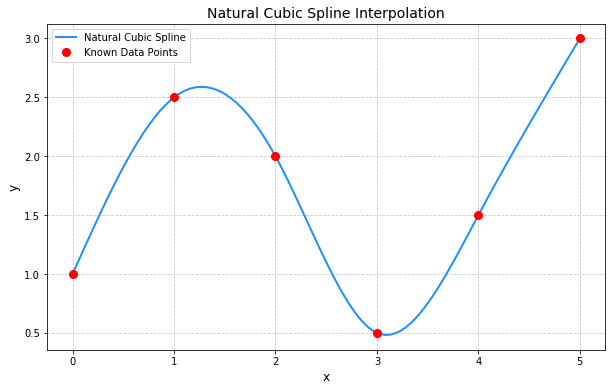

In [6]:
# Plot the Results

# Generate 100 points between the minimum and maximum x values for a smooth curve
x_curve = np.linspace(x_data[0], x_data[-1], 100)
y_curve = evaluate_spline(x_curve, x_data, y_data, M, h)

# Set up the plot
plt.figure(figsize=(10, 6))
plt.plot(x_curve, y_curve, label='Natural Cubic Spline', color='dodgerblue', linewidth=2)
plt.plot(x_data, y_data, 'ro', label='Known Data Points', markersize=8)

# Add titles and labels
plt.title('Natural Cubic Spline Interpolation', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Output the plot
plt.show()